# Detecção de Anomalias em Transações Financeiras

## Objetivo

Este projeto tem como objetivo realizar uma análise exploratória de um conjunto de dados de transações financeiras utilizando Python e Pandas, identificando padrões que diferenciam transações legítimas de transações fraudulentas.

O desenvolvimento seguirá as etapas clássicas de um projeto de Ciência de Dados:

1. Coleta dos dados;
2. Compreensão da estrutura do conjunto de dados;
3. Limpeza e preparação;
4. Análise exploratória;
5. Extração de padrões;
6. Construção de modelos de Machine Learning.

## 1. Importação das bibliotecas

Nesta etapa serão importadas as bibliotecas necessárias para realizar a leitura e a manipulação do conjunto de dados.

A biblioteca principal utilizada será o **Pandas**, responsável por fornecer estruturas de dados eficientes, como o DataFrame.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregamento do conjunto de dados

O conjunto de dados utilizado contém informações sobre transações realizadas por cartões de crédito.

Neste projeto, o dataset será carregado diretamente de uma URL pública utilizando a função `read_csv()` da biblioteca Pandas. Essa abordagem elimina a necessidade de armazenar o arquivo no repositório, tornando o projeto mais leve e fácil de reproduzir.

In [2]:
# Dataset público de transações de cartão de crédito
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(DATASET_URL)

In [3]:
# Para mostrar as 5 primeiras linhas do dataset e confirmação visual do carregamento do dataset 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Compreensão inicial do conjunto de dados

Antes de iniciar qualquer análise, é importante conhecer a estrutura do DataFrame, verificando sua dimensão, os nomes das colunas, os tipos de dados e algumas estatísticas descritivas.

In [4]:
# Retorna uma tupla com o número de linhas e colunas do dataset
df.shape

(284807, 31)

In [5]:
# Lista o nome de todas as colunas
# Ajuda a conhecer quais atributos estão disponíveis para análise
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
# Função que informa quantidade de linhas, colunas, tipos de dados e quantidade de valores nulos por coluna
# Também mostra consumo de memória do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
# Calcula automaticamente medidas estatísticas para todas as colunas numéricas do dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 4. Verificação da qualidade dos dados

Nesta etapa será verificada a existência de valores ausentes (nulos), uma das primeiras verificações realizadas durante o processo de limpeza de dados.

In [8]:
# A função isnull() gera uma tabela contendo True para valores nulos e False para valores não nulos 
# A função sum() soma os valores True, retornando a quantidade de valores nulos por coluna
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## 5. Análise da variável alvo

A coluna `Class` identifica se uma transação é legítima ou fraudulenta.

- **0** representa uma transação normal.
- **1** representa uma transação fraudulenta.

Antes de construir qualquer modelo, é importante verificar como essas classes estão distribuídas.

In [9]:
# Método value_counts() contabiliza quantas vezes cada valor aparece na coluna
# Para este conjunto de dados, espera-se encontrar um número muito maior de transações normais do que fradulentas
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## 6. Preparação dos dados para modelagem

Para treinar um modelo de Machine Learning, o conjunto de dados será dividido em:

- **Variáveis preditoras (`X`)**: informações utilizadas pelo modelo para reconhecer padrões;
- **Variável alvo (`y`)**: resultado que o modelo deverá prever.

Neste projeto, a coluna `Class` será utilizada como variável alvo:

- `0`: transação legítima;
- `1`: transação fraudulenta.

In [10]:
# Variáveis utilizadas pelo modelo para realizar as previsões
X = df.drop(columns="Class")

# Variável alvo que o modelo tentará prever
y = df["Class"]

In [11]:
# Confirmação das dimensões das variáveis X e y
print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (284807, 30)
Dimensões de y: (284807,)


### Divisão entre treino e teste

Os dados serão divididos em dois grupos:

- **70% para treinamento**: utilizados para o modelo aprender os padrões;
- **30% para teste**: utilizados para avaliar o modelo em transações que ele não viu durante o treinamento.

A divisão estratificada preserva, nos dois grupos, aproximadamente a mesma proporção de transações legítimas e fraudulentas existente no conjunto original.

In [12]:
# test_size: 30% do dataset será utilizado para teste
# random_state: garante que a divisão do dataset seja sempre a mesma
# stratify: garante que a proporção entre fraudes e não fraudes seja preservada
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [13]:
print(f"Dados de treino: {X_train.shape[0]} transações")
print(f"Dados de teste: {X_test.shape[0]} transações")

print("\nDistribuição percentual no treino:")
print(y_train.value_counts(normalize=True).mul(100))

print("\nDistribuição percentual no teste:")
print(y_test.value_counts(normalize=True).mul(100))

Dados de treino: 199364 transações
Dados de teste: 85443 transações

Distribuição percentual no treino:
Class
0    99.827451
1     0.172549
Name: proportion, dtype: float64

Distribuição percentual no teste:
Class
0    99.826785
1     0.173215
Name: proportion, dtype: float64


## 7. Treinamento do modelo de Regressão Logística

A Regressão Logística é um modelo de classificação utilizado para estimar a probabilidade de uma observação pertencer a determinada classe.

Neste projeto, ela será utilizada como **modelo de referência (baseline)**. Seu desempenho servirá como ponto de comparação para técnicas e modelos posteriores.

Antes do treinamento, as variáveis serão padronizadas com `StandardScaler`, evitando que atributos com escalas muito diferentes prejudiquem o processo de otimização do modelo.

In [14]:
# A Pipeline agrupa dois passos: a padronização dos dados e o treinamento do modelo
# O StandardScaler padroniza os dados para que tenham média 0 e desvio padrão
# O LogisticRegression é o modelo de regressão logística que será treinado com os dados padronizados
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [15]:
# Treinamento do modelo com os dados de treino
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
# Previsões para transações que o modelo não viu durante o treinamento
y_pred = logistic_model.predict(X_test)

In [17]:
# Visualização das primeiras previsões e dos respectivos valores reais
prediction_comparison = pd.DataFrame(
    {
        "Classe real": y_test.iloc[:10].values,
        "Classe prevista": y_pred[:10]
    }
)

prediction_comparison

,Classe real,Classe prevista
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


## 8. Avaliação do modelo

Como o conjunto de dados é altamente desbalanceado, a acurácia isoladamente pode produzir uma impressão enganosa sobre a qualidade do modelo.

As principais métricas analisadas serão:

- **Precision**: entre as transações classificadas como fraude, quantas realmente eram fraudulentas;
- **Recall**: entre todas as fraudes reais, quantas o modelo conseguiu identificar;
- **F1-score**: média harmônica entre precision e recall;
- **Accuracy**: proporção total de previsões corretas.

Neste problema, será dada atenção especial ao **recall da classe 1**, pois uma fraude não identificada representa uma transação fraudulenta que passou despercebida.

In [18]:
# Avaliação do modelo com métricas de classificação
# Valores exatos podem diferir um pouco dos apresentados no vídeo do bootcamp
# Foi feita divisão própria dos dados, padronização e e imports de bibliotecas que podem produzir pequenas diferenças
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Transação normal", "Fraude"],
        digits=4
    )
)

                  precision    recall  f1-score   support

Transação normal     0.9993    0.9998    0.9996     85295
          Fraude     0.8505    0.6149    0.7137       148

        accuracy                         0.9991     85443
       macro avg     0.9249    0.8073    0.8566     85443
    weighted avg     0.9991    0.9991    0.9991     85443



In [19]:
# Matriz de confusão
# Produzirá uma tabela 2x2 mostrando a quantidade de acertos e erros do modelo para cada classe 
# O campo que pode levantar preocupação é o "Previsto: normal" na linha "Real: fraude", que indica a quantidade de fraudes que o modelo classificou erroneamente como transações normais
from sklearn.metrics import confusion_matrix

confusion_matrix_result = confusion_matrix(y_test, y_pred)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix_result,
    index=["Real: normal", "Real: fraude"],
    columns=["Previsto: normal", "Previsto: fraude"]
)

confusion_matrix_df

,Previsto: normal,Previsto: fraude
Real: normal,85279,16
Real: fraude,57,91


## 9. Curva ROC e métrica ROC-AUC

A curva ROC avalia o comportamento do modelo em diferentes limiares de classificação.

- O eixo horizontal representa a taxa de falsos positivos;
- O eixo vertical representa a taxa de verdadeiros positivos, equivalente ao recall;
- Uma curva próxima do canto superior esquerdo indica melhor desempenho;
- Uma linha diagonal representa um classificador semelhante a uma decisão aleatória.

A métrica ROC-AUC resume a área abaixo dessa curva. Valores próximos de `1` indicam maior capacidade de separação entre as classes, enquanto valores próximos de `0.5` indicam um comportamento próximo do aleatório.

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probabilidade prevista de cada transação pertencer à classe de fraude
y_probability = logistic_model.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(
    y_test,
    y_probability
)

roc_auc = roc_auc_score(y_test, y_probability)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9567


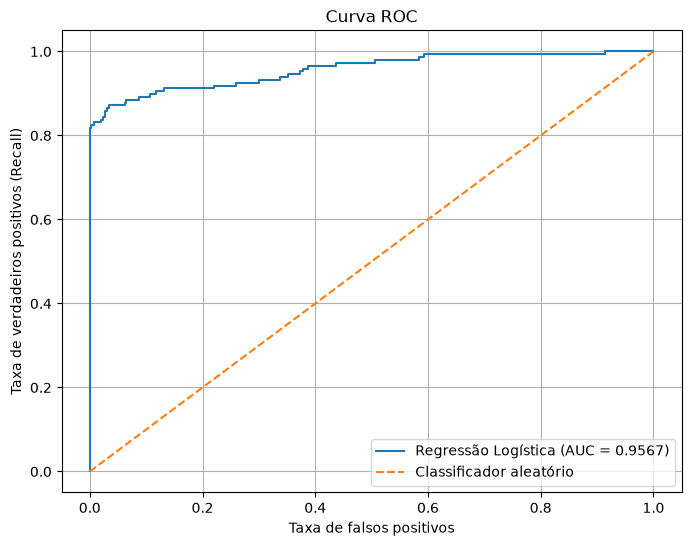

In [21]:
# Gráfico da curva ROC
plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Regressão Logística (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

## 10. Curva Precision-Recall

A curva Precision-Recall é particularmente relevante em conjuntos de dados desbalanceados.

Ela mostra o equilíbrio entre:

- **Recall**: proporção das fraudes reais que foram identificadas;
- **Precision**: proporção dos alertas de fraude que estavam corretos.

Em geral, aumentar o recall faz com que o modelo identifique mais fraudes, mas também pode aumentar os falsos positivos e reduzir a precision. Esse equilíbrio é chamado de **trade-off**.

In [22]:
# Avaliação do modelo com métricas de classificação (precisão média e curva de precisão-recall)
from sklearn.metrics import average_precision_score, precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_probability
)

average_precision = average_precision_score(y_test, y_probability)

print(f"Average Precision: {average_precision:.4f}")

Average Precision: 0.7080


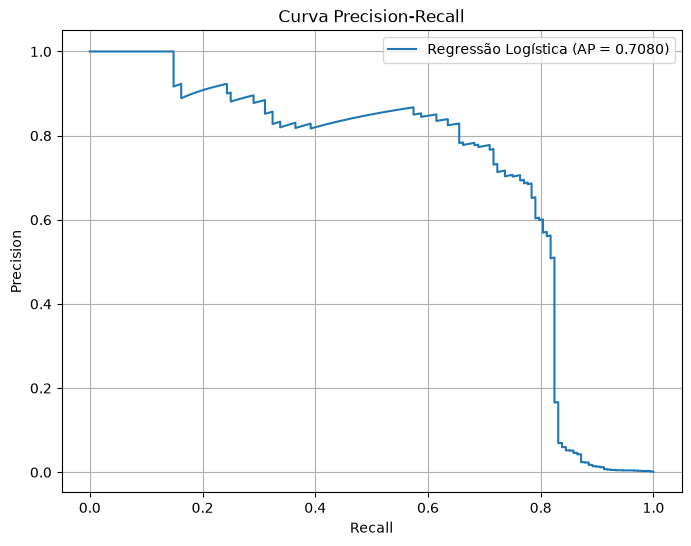

In [23]:
# Gráfico da curva Precision-Recall
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Regressão Logística (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid()
plt.show()

## 11. Ajuste do limiar de decisão

Por padrão, modelos de classificação binária geralmente utilizam o limiar de `0.5`.

Isso significa que:

- se a probabilidade prevista for maior ou igual a `0.5`, a transação é classificada como fraude;
- se a probabilidade prevista for menor que `0.5`, a transação é classificada como normal.

Em problemas de fraude, pode ser interessante reduzir esse limiar para aumentar o **recall**, ou seja, identificar uma quantidade maior de fraudes reais.

Neste teste, será utilizado o limiar de `0.3`.

In [24]:
# Ajuste do threshold de classificação
# O threshold padrão é 0.5, mas pode ser ajustado para melhorar a detecção de fraudes

threshold = 0.30

y_pred_threshold = (y_probability >= threshold).astype(int)

In [25]:
print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=["Transação normal", "Fraude"],
        digits=4
    )
)

                  precision    recall  f1-score   support

Transação normal     0.9994    0.9997    0.9995     85295
          Fraude     0.7823    0.6554    0.7132       148

        accuracy                         0.9991     85443
       macro avg     0.8908    0.8275    0.8564     85443
    weighted avg     0.9990    0.9991    0.9990     85443



In [26]:
# Matriz de confusão com threshold ajustado
confusion_matrix_threshold = confusion_matrix(y_test, y_pred_threshold)

confusion_matrix_threshold_df = pd.DataFrame(
    confusion_matrix_threshold,
    index=["Real: normal", "Real: fraude"],
    columns=["Previsto: normal", "Previsto: fraude"]
)

confusion_matrix_threshold_df

,Previsto: normal,Previsto: fraude
Real: normal,85268,27
Real: fraude,51,97


## 12. Treinamento do modelo Random Forest

O Random Forest é um modelo baseado em múltiplas árvores de decisão.

Cada árvore aprende padrões diferentes dos dados e, ao final, o modelo combina essas decisões para produzir uma previsão mais robusta.

Neste projeto, o Random Forest será utilizado com `class_weight="balanced"`, fazendo com que o modelo dê mais peso à classe minoritária, ou seja, às transações fraudulentas.

In [27]:
# n_estimators=50: cria 50 árvores de decisão
# max_depth=5: limita a profundidade máxima de cada árvore para evitar overfitting
# class_weight="balanced": dá mais peso para a classe minoritária
# random_state=42: define a semente do gerador de números aleatórios para reprodutibilidade
# n_jobs=-1: utiliza todos os núcleos de CPU disponíveis para paralelizar o treinamento do modelo
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [28]:
random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featur

In [29]:
random_forest_y_pred = random_forest_model.predict(X_test)
random_forest_y_probability = random_forest_model.predict_proba(X_test)[:, 1]

In [30]:
print(
    classification_report(
        y_test,
        random_forest_y_pred,
        target_names=["Transação normal", "Fraude"],
        digits=4
    )
)

                  precision    recall  f1-score   support

Transação normal     0.9997    0.9972    0.9985     85295
          Fraude     0.3416    0.8378    0.4853       148

        accuracy                         0.9969     85443
       macro avg     0.6707    0.9175    0.7419     85443
    weighted avg     0.9986    0.9969    0.9976     85443



In [31]:
confusion_matrix_random_forest = confusion_matrix(y_test, random_forest_y_pred)

confusion_matrix_random_forest_df = pd.DataFrame(
    confusion_matrix_random_forest,
    index=["Real: normal", "Real: fraude"],
    columns=["Previsto: normal", "Previsto: fraude"]
)

confusion_matrix_random_forest_df

,Previsto: normal,Previsto: fraude
Real: normal,85056,239
Real: fraude,24,124


In [32]:
random_forest_roc_auc = roc_auc_score(y_test, random_forest_y_probability)
random_forest_average_precision = average_precision_score(y_test, random_forest_y_probability)

print(f"ROC-AUC Random Forest: {random_forest_roc_auc:.4f}")
print(f"Average Precision Random Forest: {random_forest_average_precision:.4f}")

ROC-AUC Random Forest: 0.9693
Average Precision Random Forest: 0.6979


## 13. Comparação dos modelos

Após treinar diferentes abordagens, os resultados serão reunidos em uma tabela comparativa.

A comparação será feita considerando as métricas mais relevantes para a classe de fraude:

- Precision;
- Recall;
- F1-score;
- ROC-AUC;
- Average Precision.

Como o conjunto de dados é desbalanceado, o foco principal não será a acurácia, mas sim a capacidade de identificar fraudes reais.

In [33]:
from sklearn.metrics import precision_recall_fscore_support

# Função para calcular métricas de fraude
# Sempre vai extrair as mesmas métricas da classe fraude
def get_fraud_metrics(model_name, y_true, y_pred, y_score):
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1],
        zero_division=0
    )

    return {
        "Modelo": model_name,
        "Precision (fraude)": precision[0],
        "Recall (fraude)": recall[0],
        "F1-score (fraude)": f1_score[0],
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Average Precision": average_precision_score(y_true, y_score)
    }

In [34]:
# Comparação dos modelos
# Resulta em uma tabela comparando os três modelos treinados: Regressão Logística, Regressão Logística com threshold ajustado e Random Forest Balanceado

comparison_results = pd.DataFrame(
    [
        get_fraud_metrics(
            "Regressão Logística",
            y_test,
            y_pred,
            y_probability
        ),
        get_fraud_metrics(
            "Regressão Logística - Threshold 0.3",
            y_test,
            y_pred_threshold,
            y_probability
        ),
        get_fraud_metrics(
            "Random Forest Balanceado",
            y_test,
            random_forest_y_pred,
            random_forest_y_probability
        )
    ]
)

comparison_results

,Modelo,Precision (fraude),Recall (fraude),F1-score (fraude),ROC-AUC,Average Precision
0,Regressão Logística,0.850467,0.614865,0.713725,0.956719,0.707952
1,Regressão Logística - Threshold 0.3,0.782258,0.655405,0.713235,0.956719,0.707952
2,Random Forest Balanceado,0.341598,0.837838,0.485323,0.969258,0.697879


In [35]:
comparison_results.set_index("Modelo").round(4)

,Precision (fraude),Recall (fraude),F1-score (fraude),ROC-AUC,Average Precision
Modelo,,,,,
Regressão Logística,0.8505,0.6149,0.7137,0.9567,0.7080
Regressão Logística - Threshold 0.3,0.7823,0.6554,0.7132,0.9567,0.7080
Random Forest Balanceado,0.3416,0.8378,0.4853,0.9693,0.6979


## 14. Importância das variáveis

Modelos baseados em árvores, como o Random Forest, permitem analisar a importância das variáveis utilizadas na decisão.

Essa análise ajuda a entender quais atributos tiveram maior influência para o modelo classificar uma transação como normal ou fraudulenta.

In [36]:
# Gera uma tabela com as 10 variáveis mais importantes para o modelo Random Forest

feature_importance = pd.DataFrame(
    {
        "Variável": X_train.columns,
        "Importância": random_forest_model.feature_importances_
    }
).sort_values(by="Importância", ascending=False)

feature_importance.head(10)

,Variável,Importância
14,V14,0.316821
17,V17,0.109386
10,V10,0.107352
4,V4,0.097640
3,V3,0.093413
12,V12,0.077298
16,V16,0.052478
2,V2,0.022948
9,V9,0.022144
7,V7,0.017051


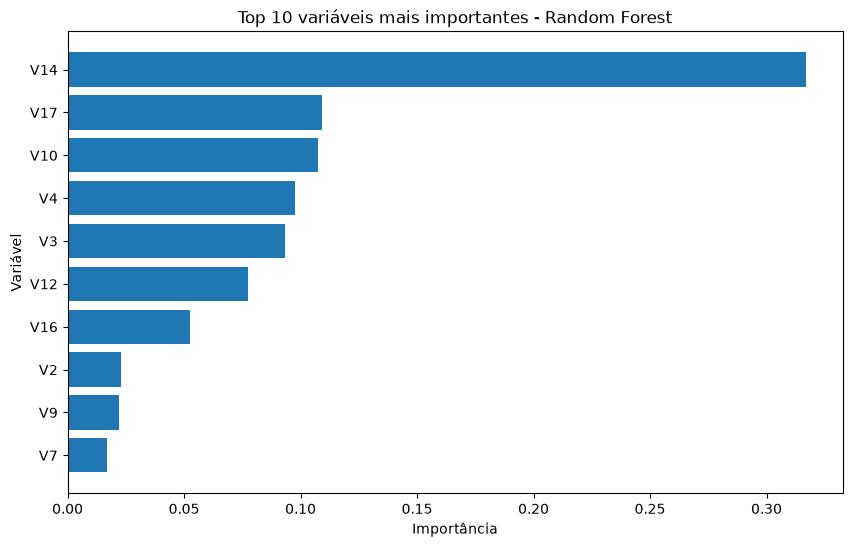

In [37]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Variável"], top_features["Importância"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Top 10 variáveis mais importantes - Random Forest")
plt.gca().invert_yaxis()
plt.show()